In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

%matplotlib inline

In [18]:
# Methane potential reference
# Constants
A = np.array([0.262373610e7,  0.265413949e7,  0.241399203e6, -0.271732286e6, -0.749715218e5, 0.123654939e6])
alpha = np.array([0.16878421e1, 0.28827219e1, 0.35917561e1, 0.16490747e1, 0.20593086e1, 0.21451641e1])
b = np.array([0.168275675e1, 0.288261054e1, 0.384703188e1, 0.155011960e1, 0.266424603e1, 0.304993944e1])
C6 = np.array([0.112317356e7, -0.139633537e7, 0.294147230e6, 0.127844394e7, 0.169329268e6,  -0.590727146e6])
C8 = np.array([-0.120939119e9, 0.385078060e8,  -0.264781786e7, 0.174762764e7,  -0.810401688e7, 0.679543866e7])
qH = 0.94753e2
qC = -0.379012e3
b_corr = 0.177e1
delta_C6 = 0.45347e5
delta_C8 = 0.432463e6

num_sites = 9

def calc_potential(r, A, b, alpha, C6, C8, q1, q2):
    expTerm = A * np.exp(-alpha * r)
    f6 = 1.0 - np.exp(-b*r) * (1.0 + (b*r) + ((b*r)**2) / 2. + ((b*r)**3) / 6. + ((b*r)**4) / 24. + ((b*r)**5) / 120. + ((b*r)**6) / 720.)
    f8 = f6 - np.exp(-b*r) * (((b*r)**7) / 5040. + ((b*r)**8) / 40320.)
    return expTerm - (C6 / (r**6)) * f6 - (C8 / (r**8)) * f8 + q1 * q2 / r

def calc_potential_correction(r, b_corr, delta_C6, delta_C8):
    f6 = 1.0 - np.exp(-b_corr*r) * (1.0 + (b_corr*r) + ((b_corr*r)**2) / 2. + ((b_corr*r)**3) / 6. + ((b_corr*r)**4) / 24. + ((b_corr*r)**5) / 120. + ((b_corr*r)**6) / 720.)
    f8 = f6 - np.exp(-b_corr*r) * (((b_corr*r)**7) / 5040. + ((b_corr*r)**8) / 40320.)
    return - (delta_C6 / (r**6)) * f6 - (delta_C8 / (r**8)) * f8

def make_tetra_sites1(factor):
    dist_CH = 1.099
    site_dist = factor * dist_CH
    site_positions = np.array([[-site_dist, 0.0, 0.0],
                              [site_dist / 3., site_dist * (2.* np.sqrt(2.) / 3.), 0.0],
                              [site_dist / 3., - site_dist * np.sqrt(2.) / 3., site_dist * np.sqrt(6.) / 3.],
                              [site_dist / 3., - site_dist * np.sqrt(2.) / 3., - site_dist * np.sqrt(6.) / 3.]])
    return site_positions

def make_tetra_sites(factor):
    inv_sqrt3 = 1. / np.sqrt(3.0)
    dist_CH = 1.099
    site_dist = factor * dist_CH * inv_sqrt3
    site_positions = np.array([[site_dist, site_dist, site_dist],
                              [site_dist, -site_dist, -site_dist],
                              [-site_dist, site_dist, -site_dist],
                              [-site_dist, -site_dist, site_dist]])
    return site_positions


def distance(pos1, pos2):
    return np.linalg.norm(pos2 - pos1)


pos1 = np.vstack((np.array([[0.0, 0.0, 0.0]]), make_tetra_sites1(0.88), make_tetra_sites1(-0.66)))

rotation_180z = R.from_euler('z', 180., degrees=True)
pos2 = rotation_180z.apply(pos1)

rotation_half109leftz = R.from_euler('z', -54.75, degrees=True)
pos3 = rotation_half109leftz.apply(pos1)

rotation_half109rightz = R.from_euler('z', 125.25, degrees=True)
pos4 = rotation_half109rightz.apply(pos1)


sites_P1 = pos2
dx = 0.001
dists_ref = np.arange(2.5, 8.5, dx)

pot_energy = np.zeros_like(dists_ref)
pot_energy_corrected = np.zeros_like(dists_ref)
for idx, shift in enumerate(dists_ref):
    
    sites_P2 = pos1 + np.array([shift, 0.0, 0.0])
    pot_sum = 0.0
    
    # C-C
    pot_sum += calc_potential(distance(sites_P1[0], sites_P2[0]), A[0], b[0], alpha[0], C6[0], C8[0], qC, qC)
    # C-H
    for i in range(4):
        pot_sum += calc_potential(distance(sites_P1[0], sites_P2[1+i]), A[1], b[1], alpha[1], C6[1], C8[1], qC, qH)
        pot_sum += calc_potential(distance(sites_P1[1+i], sites_P2[0]), A[1], b[1], alpha[1], C6[1], C8[1], qC, qH)
    # H-H
    for i in range(4):
        for j in range(4):
            pot_sum += calc_potential(distance(sites_P1[1+i], sites_P2[1+j]), A[2], b[2], alpha[2], C6[2], C8[2], qH, qH)
    # C-E
    for i in range(4):
        pot_sum += calc_potential(distance(sites_P1[0], sites_P2[5+i]), A[3], b[3], alpha[3], C6[3], C8[3], qC, 0.0)
        pot_sum += calc_potential(distance(sites_P1[5+i], sites_P2[0]), A[3], b[3], alpha[3], C6[3], C8[3], qC, 0.0)
    # H-E
    for i in range(4):
        for j in range(4):
            pot_sum += calc_potential(distance(sites_P1[1+i], sites_P2[5+j]), A[4], b[4], alpha[4], C6[4], C8[4], qH, 0.0)
            pot_sum += calc_potential(distance(sites_P1[5+i], sites_P2[1+j]), A[4], b[4], alpha[4], C6[4], C8[4], qH, 0.0)
    # E-E
    for i in range(4):
        for j in range(4):
            pot_sum += calc_potential(distance(sites_P1[5+i], sites_P2[5+j]), A[5], b[5], alpha[5], C6[5], C8[5], 0.0, 0.0)
            
    pot_energy[idx] = pot_sum
    pot_energy_corrected[idx] = pot_sum + calc_potential_correction(distance(sites_P1[0], sites_P2[0]), b_corr, delta_C6, delta_C8)
    
force = - np.gradient(pot_energy_corrected, dx)

In [19]:
paper_dists = np.array([2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0, 5.5, 6.0, 6.5, 7.0, 8.0])
paper_energy_fit = np.array([8155.60, 2777.63, 676.192, -58.840, -257.529, -265.580, -218.941, -166.389, -122.429, -89.205, -65.108, -35.580, -20.332, -12.152, -7.570, -3.276])
paper_energy_abinitio = np.array([7843.67, 2727.14, 678.222, -52.924, -255.262, -266.072, -220.489, -167.941, -123.586, -89.924, -65.510, -35.669, -20.375, -12.218, -7.645, -3.323])

indices = [np.abs(dists_ref - v).argmin() for v in paper_dists]
diff_to_paper = paper_energy_fit - pot_energy[indices]
print(diff_to_paper)

max_well_depth_paper = 273.9 # Kelvin
max_well_distance_paper = 3.633 # Angstöm
max_well_depth_notebook = np.min(pot_energy_corrected)
max_well_distance_notebook = dists_ref[np.argmin(pot_energy_corrected)]
print("Maximum well depth of {} K at {} A".format(max_well_depth_notebook, max_well_distance_notebook))

[-1.02765125e+05 -4.93424394e+04 -2.29088565e+04 -1.02907305e+04
 -4.45688280e+03 -1.84190386e+03 -7.09121869e+02 -2.39283600e+02
 -5.65669392e+01  6.77581482e+00  2.33661255e+01  1.89304253e+01
  1.01084986e+01  5.12637938e+00  2.70280132e+00  8.92774109e-01]
Maximum well depth of -99.81790137380212 K at 4.775999999999749 A


In [20]:
filename = "methane-2b-linear"
folder = "cmake-build-debug"

path = folder + "/" + filename + ".csv"

In [21]:
df = pd.read_csv(path)

In [22]:
df["Force Mag"] = np.sign(df["Force_x [K/A]"]) * np.linalg.norm(df[['Force_x [K/A]', 'Force_y [K/A]', 'Force_z [K/A]']].values, axis=1)
df.head()

,Distance [A],Energy [K],Force_x [K/A],Force_y [K/A],Force_z [K/A],Force Mag
0,2.5,110920.725240,326989.599828,1.665500e-11,2.270000e-13,326989.599828
1,2.6,82362.115831,247590.849570,1.153900e-11,3.410000e-13,247590.849570
2,2.7,60798.173453,186364.240083,-9.720000e-12,1.710000e-13,186364.240083
3,2.8,44613.782003,139427.636915,5.286000e-12,-2.270000e-13,139427.636915
4,2.9,32539.876283,103693.849491,2.387000e-12,0.000000e+00,103693.849491


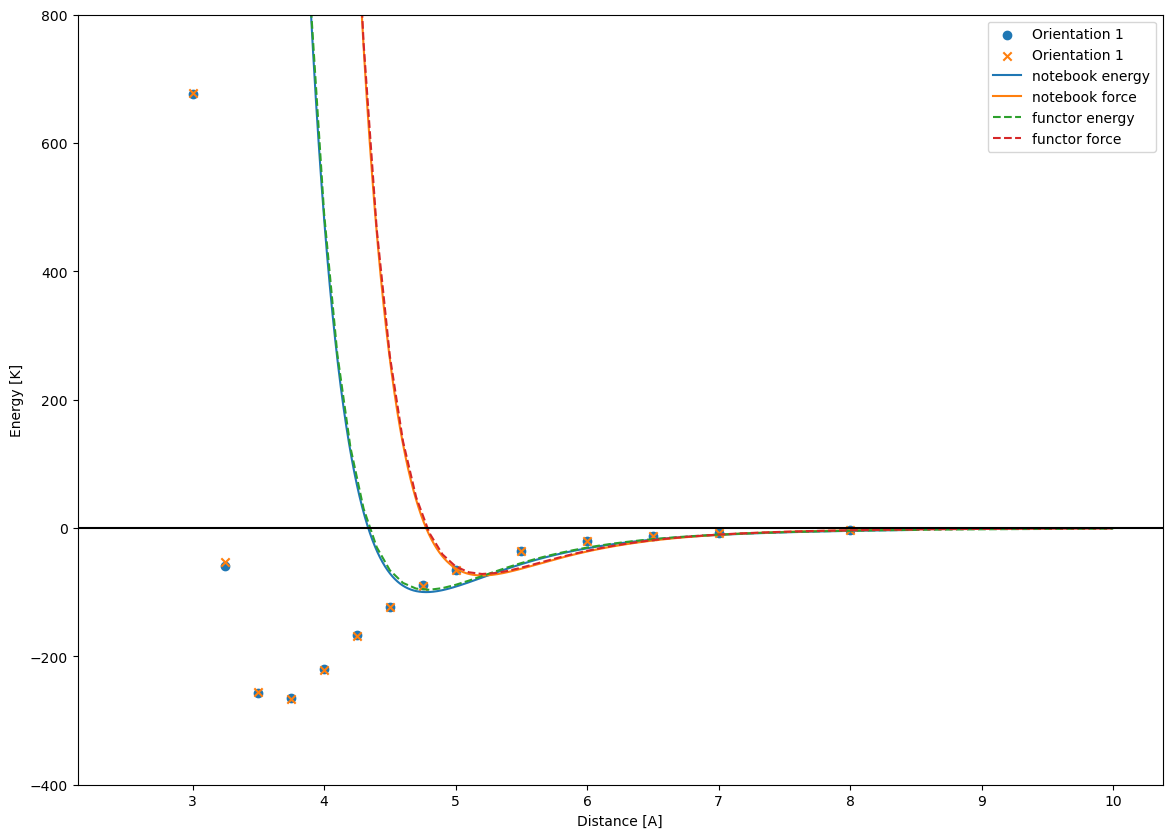

In [23]:
fig, ax = plt.subplots(figsize=(14, 10))


ax.scatter(paper_dists, paper_energy_fit, label="Orientation 1")
ax.scatter(paper_dists, paper_energy_abinitio, label="Orientation 1", marker='x')
ax.plot(dists_ref, pot_energy_corrected, label="notebook energy")
ax.plot(dists_ref, force, label="notebook force")
ax.plot(df["Distance [A]"], df["Energy [K]"], label="functor energy", linestyle='--')
ax.plot(df["Distance [A]"], df["Force Mag"], label="functor force", linestyle='--')

ax.axhline(y=0.0, color='k', linestyle='-')

ax.set_ylabel("Energy [K]")
ax.set_xlabel("Distance [A]")

ax.set_ylim(-400, 800)
ax.legend()

plt.show()